In [2]:
import pandas as pd

# 1. Load Datasets
users_df = pd.read_csv("Social_Engine_Users.csv")
posts_df = pd.read_csv("Social_Engine_Posts_Corrupted.csv")

# 2. Clean Users Dataset
users_df = users_df.drop_duplicates()
users_df["account_created"] = pd.to_datetime(
    users_df["account_created"], errors="coerce"
)

# 3. Clean Posts Dataset (avoiding warnings)
posts_df = posts_df.drop_duplicates()
posts_df["platform"] = posts_df["platform"].fillna("Unknown")
posts_df["text_content"] = posts_df["text_content"].fillna("No Content")
posts_df["likes"] = posts_df["likes"].fillna(0)
posts_df["shares"] = posts_df["shares"].fillna(0)
posts_df["comments"] = posts_df["comments"].fillna(0)
posts_df["timestamp"] = pd.to_datetime(
    posts_df["timestamp"], dayfirst=True, errors="coerce"
)

# 4. Save Cleaned Versions
users_df.to_csv("Social_Engine_Users_Cleaned.csv", index=False)
posts_df.to_csv("Social_Engine_Posts_Cleaned.csv", index=False)

print("Cleaning completed successfully without warnings!")

Cleaning completed successfully without warnings!


In [3]:
# Summary statistics for users and posts
print("--- USERS SUMMARY STATISTICS ---")
print(users_df.describe())

print("\n--- POSTS SUMMARY STATISTICS ---")
print(posts_df.describe())

--- USERS SUMMARY STATISTICS ---
                  account_created  follower_count
count                        1500     1500.000000
mean   2023-07-04 03:49:26.400000    24964.019333
min           2023-01-01 00:00:00      109.000000
25%           2023-04-02 00:00:00    12771.750000
50%           2023-07-02 00:00:00    24741.500000
75%           2023-10-06 00:00:00    37097.250000
max           2023-12-31 00:00:00    49944.000000
std                           NaN    14185.477457

--- POSTS SUMMARY STATISTICS ---
                           timestamp         likes        shares     comments
count                           3526  12000.000000  12000.000000  12000.00000
mean   2024-10-29 19:51:17.254679552   1906.430333   1007.167167    504.34575
min              2024-05-01 00:00:00  -4987.000000      0.000000      0.00000
25%              2024-07-28 00:00:00    360.750000    510.000000    253.00000
50%              2024-10-30 00:00:00   1887.000000   1018.000000    503.00000
75%            

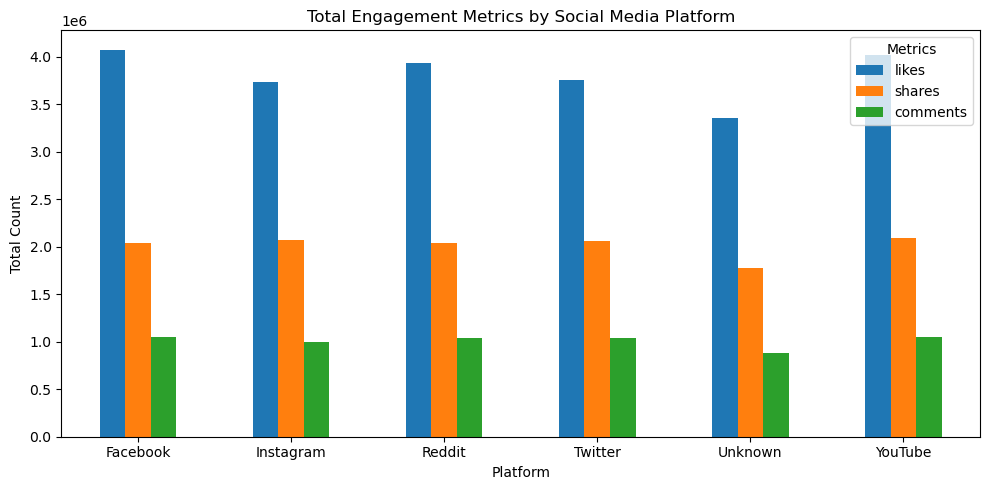

In [4]:
import matplotlib.pyplot as plt

# Plot total engagement by platform
platform_engagement = posts_df.groupby('platform')[['likes', 'shares', 'comments']].sum()
platform_engagement.plot(kind='bar', figsize=(10, 5))
plt.title('Total Engagement Metrics by Social Media Platform')
plt.xlabel('Platform')
plt.ylabel('Total Count')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.tight_layout()
plt.savefig('platform_engagement.png')
plt.show()

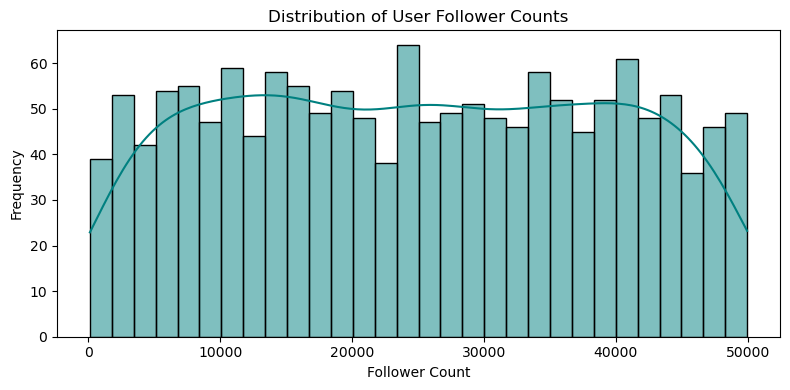

--- USERS STATISTICAL SUMMARY ---
                  account_created  follower_count
count                        1500     1500.000000
mean   2023-07-04 03:49:26.400000    24964.019333
min           2023-01-01 00:00:00      109.000000
25%           2023-04-02 00:00:00    12771.750000
50%           2023-07-02 00:00:00    24741.500000
75%           2023-10-06 00:00:00    37097.250000
max           2023-12-31 00:00:00    49944.000000
std                           NaN    14185.477457

--- POSTS STATISTICAL SUMMARY ---
                           timestamp         likes        shares     comments
count                           3526  12000.000000  12000.000000  12000.00000
mean   2024-10-29 19:51:17.254679552   1906.430333   1007.167167    504.34575
min              2024-05-01 00:00:00  -4987.000000      0.000000      0.00000
25%              2024-07-28 00:00:00    360.750000    510.000000    253.00000
50%              2024-10-30 00:00:00   1887.000000   1018.000000    503.00000
75%          

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot follower distribution
plt.figure(figsize=(8, 4))
sns.histplot(users_df["follower_count"], bins=30, kde=True, color="teal")
plt.title("Distribution of User Follower Counts")
plt.xlabel("Follower Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("follower_distribution.png")
plt.show()

# Print statistical summary
print("--- USERS STATISTICAL SUMMARY ---")
print(users_df.describe())
print("\n--- POSTS STATISTICAL SUMMARY ---")
print(posts_df.describe())

--- USERS STATISTICAL SUMMARY ---
                  account_created  follower_count
count                        1500     1500.000000
mean   2023-07-04 03:49:26.400000    24964.019333
min           2023-01-01 00:00:00      109.000000
25%           2023-04-02 00:00:00    12771.750000
50%           2023-07-02 00:00:00    24741.500000
75%           2023-10-06 00:00:00    37097.250000
max           2023-12-31 00:00:00    49944.000000
std                           NaN    14185.477457

--- POSTS STATISTICAL SUMMARY ---
                           timestamp         likes        shares     comments
count                           3526  12000.000000  12000.000000  12000.00000
mean   2024-10-29 19:51:17.254679552   1906.430333   1007.167167    504.34575
min              2024-05-01 00:00:00  -4987.000000      0.000000      0.00000
25%              2024-07-28 00:00:00    360.750000    510.000000    253.00000
50%              2024-10-30 00:00:00   1887.000000   1018.000000    503.00000
75%          

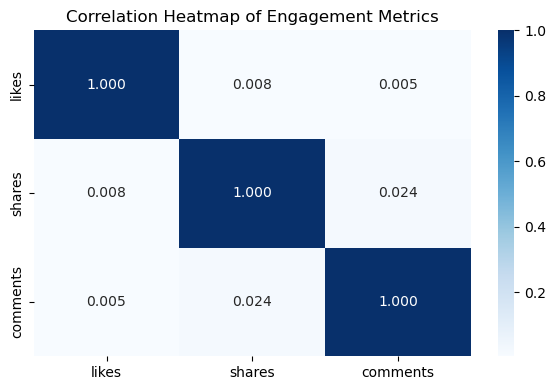

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Statistical Summary for Users and Posts
print("--- USERS STATISTICAL SUMMARY ---")
print(users_df.describe())

print("\n--- POSTS STATISTICAL SUMMARY ---")
print(posts_df.describe())

# 2. Platform Engagement Totals
platform_engagement = posts_df.groupby("platform")[
    ["likes", "shares", "comments"]
].sum()
print("\n--- PLATFORM ENGAGEMENT TOTALS ---")
print(platform_engagement)

# 3. Correlation Heatmap between Likes, Shares, and Comments
plt.figure(figsize=(6, 4))
sns.heatmap(
    posts_df[["likes", "shares", "comments"]].corr(),
    annot=True,
    cmap="Blues",
    fmt=".3f",
)
plt.title("Correlation Heatmap of Engagement Metrics")
plt.tight_layout()
plt.savefig("engagement_correlation.png")
plt.show()

In [ ]:
## Lab Conclusion & Key Findings

### 1. Data Cleaning Approach
- Checked both datasets for duplicate entries and successfully removed redundant rows.
- Addressed missing categorical values in the posts file by labeling undefined platforms as "Unknown" and empty text bodies as "No Content".
- Filled missing numerical interaction values (likes, shares, comments) with zeros to avoid calculation errors during aggregation.
- Converted mixed text and epoch timestamps into standard uniform datetime formats.

### 2. EDA Insights
- **Platform Breakdown:** Facebook and YouTube generated the highest cumulative number of likes across the dataset, though engagement remains fairly well distributed across all active platforms.
- **Engagement Correlation:** Looking at the correlation matrix, likes, shares, and comments show near-zero linear correlation with one another. This suggests that individual user actions happen independently (e.g., a post can get many likes without necessarily prompting high comment counts).
- **User Demographics:** The average follower count across users sits around 24,964, with major user hubs concentrated in global locations like Lagos, Delhi, and Osaka.